<div style="background-color:white; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> “Binary Classification for Credit Card Fraud Detection: A Machine Learning Approach” </h1>
</div>


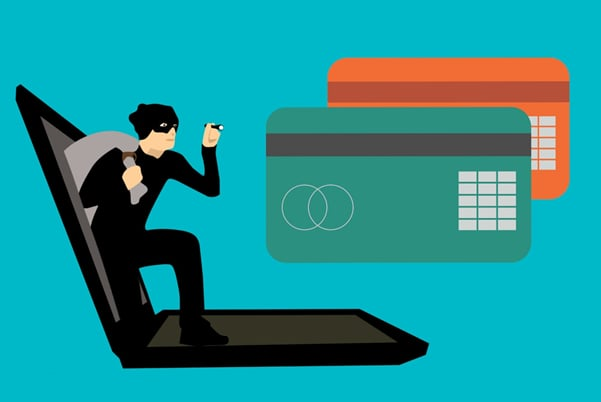

<div style="
    background-color: white;
    border: 2px solid skyblue;
    border-radius: 10px;
    padding: 15px;
    max-width: 700px;
    margin: auto;
">
    <h3 style="color:black; text-align: center;">
     **   When purchasing products online, many people prefer using credit cards due to their convenience and credit limits, which allow purchases even without immediate funds. However, these advantages can also be exploited by cyber attackers for fraudulent activities. To address this issue, it is essential to have a system that can automatically block transactions if suspicious activity is detected. Such a system should be capable of tracking the patterns of all transactions and identifying anomalies that deviate from typical behavior. If any transaction exhibits an unusual pattern, it should be flagged or aborted to prevent fraud. With advancements in technology, machine learning algorithms have emerged as effective tools for classifying abnormal transactions. By leveraging historical transaction data and selecting suitable algorithms, we can build robust systems that can accurately detect and prevent fraudulent activities in real-time.**
    </h3>
</div>


<div style="background-color:green; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Import Libraries </h1>
</div>


In [1]:
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.manifold import TSNE
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedKFold, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


<div style="background-color:DarkKhaki; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Import DATA  </h1>
</div>


The data for this article can be found here. This dataset contains the real bank transactions made by European cardholders in the year 2013. As a security concern, the actual variables are not being shared but — they have been transformed versions of PCA. As a result, we can find 29 feature columns and 1 final class column.

In [2]:
train=pd.read_csv('/kaggle/input/d/isaikumar/creditcardfraud/creditcard.csv')
test=pd.read_csv('/kaggle/input/d/isaikumar/creditcardfraud/creditcard.csv')
sample_sub=pd.read_csv('/kaggle/input/d/isaikumar/creditcardfraud/creditcard.csv')

In [3]:
train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
extra=pd.read_csv('/kaggle/input/d/isaikumar/creditcardfraud/creditcard.csv')
extra.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0




<div style="background-color:SeaGreen; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">  DATA Processing ....... </h1>
</div>


In [5]:
seconds_per_day = 3600*24
train["Day"] = train["Time"].apply(lambda x: 1 if x<seconds_per_day else 2)
train["Hour"] = train["Time"].apply(lambda x: (x%seconds_per_day)//3600 + 1)
extra["Day"] = extra["Time"].apply(lambda x: 1 if x<seconds_per_day else 2)
extra["Hour"] = extra["Time"].apply(lambda x: (x%seconds_per_day)//3600 + 1)
test["Day"] = test["Time"].apply(lambda x: 1 if x<seconds_per_day else 2)
test["Hour"] = test["Time"].apply(lambda x: (x%seconds_per_day)//3600 + 1)
train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Day,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,1,1.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1,1.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1,1.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1,1.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,1,1.0


In [6]:
df = pd.concat([train,extra ], ignore_index=True)

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Day,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,1,1.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1,1.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1,1.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1,1.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,1,1.0



<div style="background-color:SeaShell; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">  Exploratory Data Analysis ....... </h1>
</div>


In [8]:
a=df.corr().abs()>0.3

<Axes: >

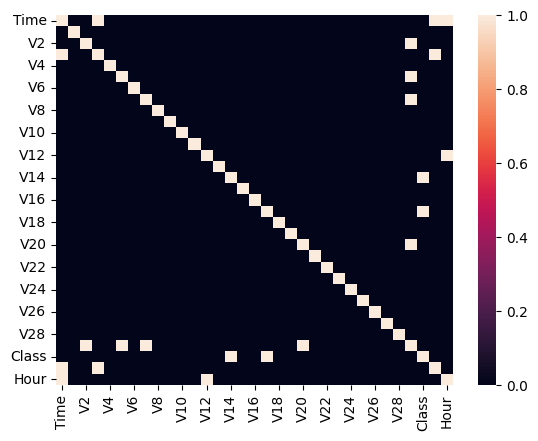

In [9]:
sns.heatmap(a)

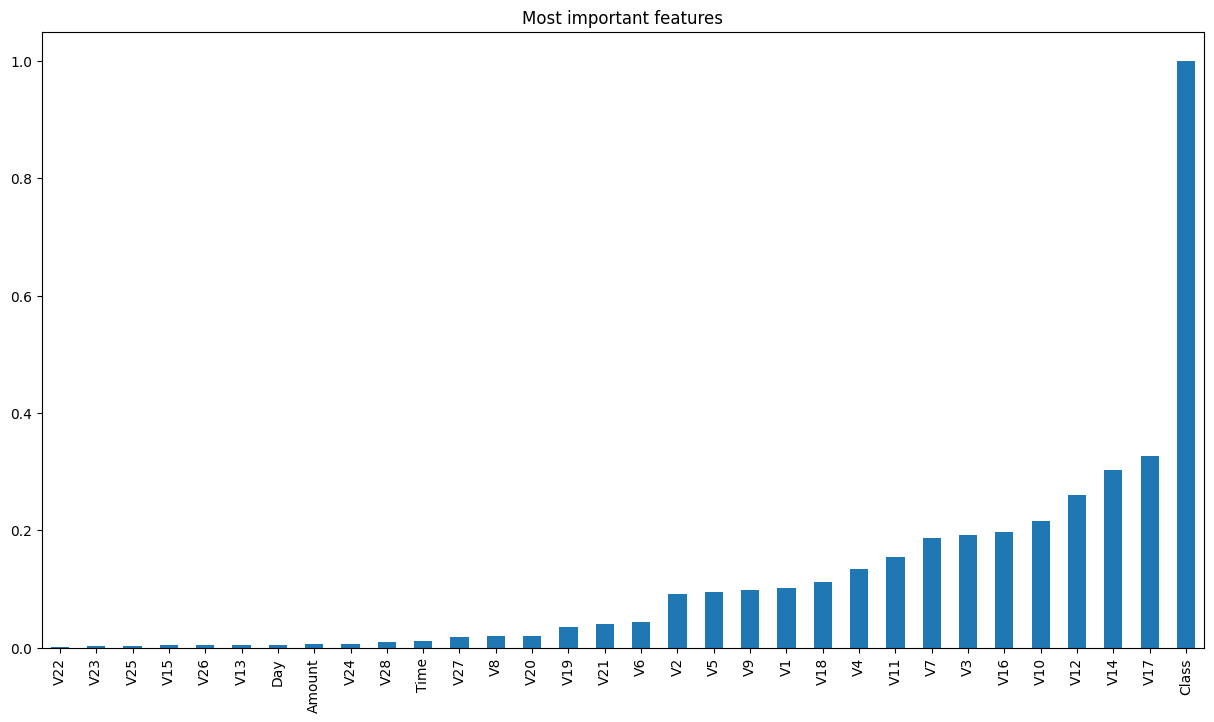

In [10]:
plt.figure(figsize=(15,8))
d = df.corr()['Class'][:-1].abs().sort_values().plot(kind='bar', title='Most important features')

plt.show()

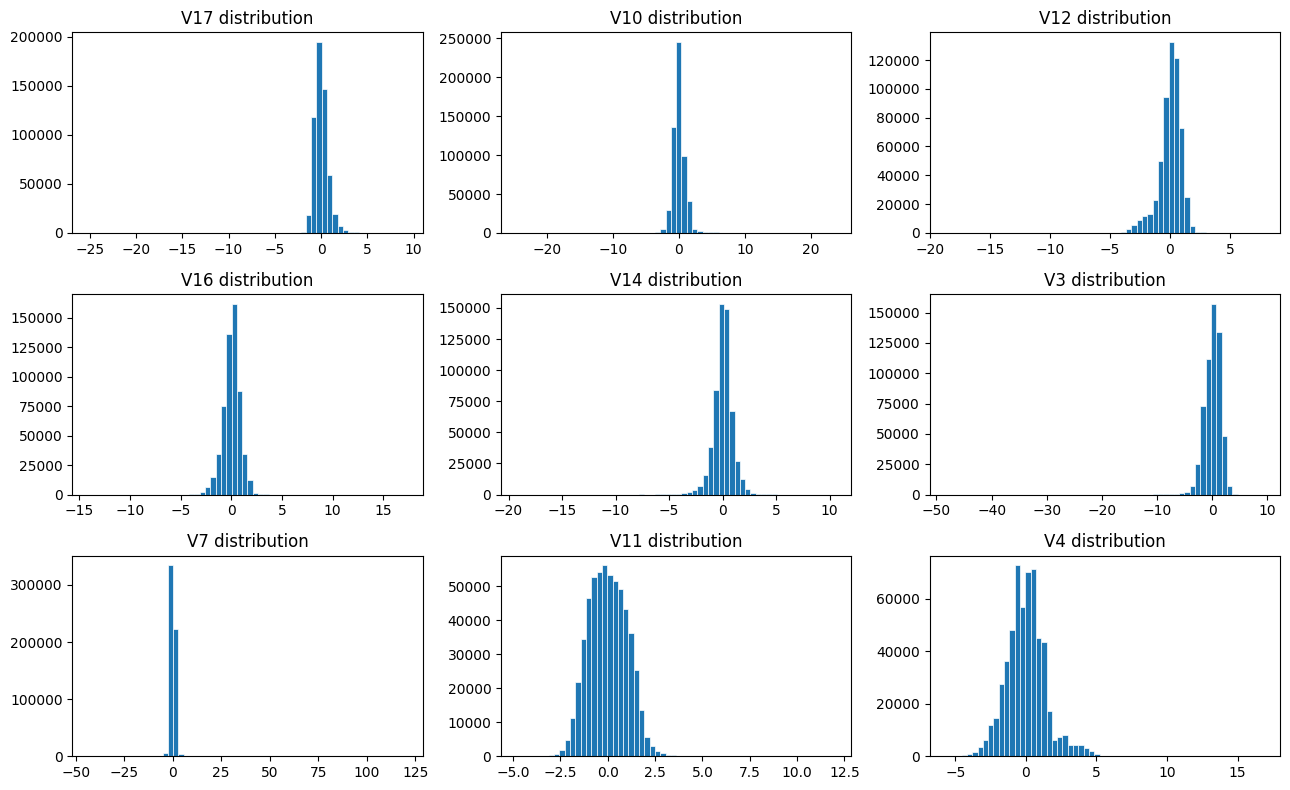

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(13,8))

axes[0,0].hist(df['V17'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,0].set_title("V17 distribution");

axes[0,1].hist(df['V10'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,1].set_title("V10 distribution");

axes[0,2].hist(df['V12'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,2].set_title("V12 distribution");

axes[1,0].hist(df['V16'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,0].set_title("V16 distribution");

axes[1,1].hist(df['V14'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,1].set_title("V14 distribution");

axes[1,2].hist(df['V3'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,2].set_title("V3 distribution");

axes[2,0].hist(df['V7'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,0].set_title("V7 distribution");

axes[2,1].hist(df['V11'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,1].set_title("V11 distribution");

axes[2,2].hist(df['V4'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,2].set_title("V4 distribution");

plt.tight_layout()

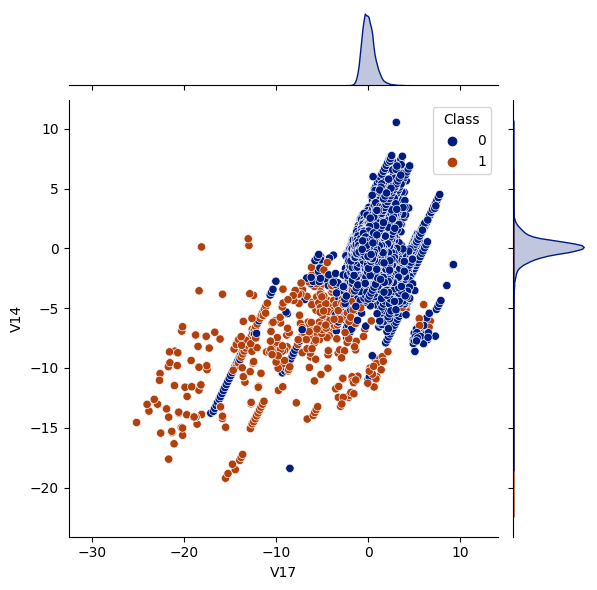

In [12]:
sns.jointplot(x='V17', y='V14',hue='Class', data=df, palette = 'dark')

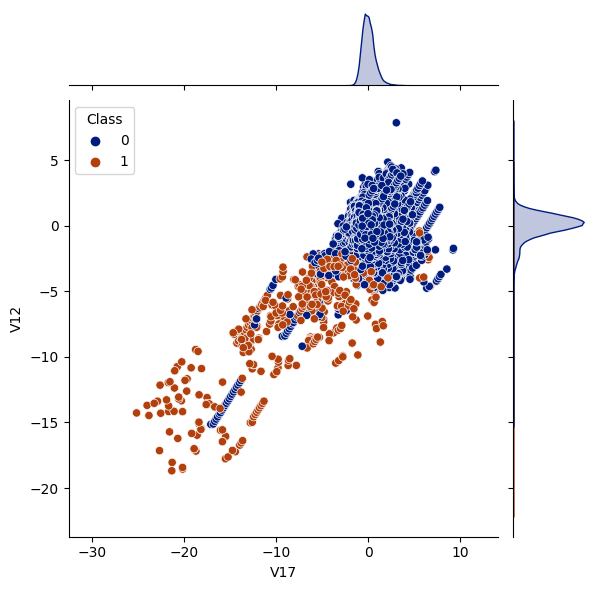

In [13]:
sns.jointplot(x='V17', y='V12',hue='Class', data=df, palette = 'dark')



<div style="background-color:white; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Data Cleaning and Preprocessing  ....... </h1>
</div>


In [14]:
print(df.columns)


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Day', 'Hour'],
      dtype='object')


In [15]:
df.drop('id', axis=1, inplace=True, errors='ignore')


 
 <div style="background-color:MediumAquaMarine; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">  Model building </h1>
</div>

In [16]:
print("Train columns:", X.columns.tolist())
print("Test columns:", test.columns.tolist())


NameError: name 'X' is not defined

In [ ]:
test = test.drop('Class', axis=1)


In [ ]:
y = train['Class']
X = train.drop('Class', axis=1)


sc = StandardScaler()
X = pd.DataFrame(sc.fit_transform(X.values), columns=X.columns, index=X.index)
test = pd.DataFrame(sc.transform(test.values), columns=test.columns, index=test.index)

In [ ]:
lgbm_params = {'n_estimators': 100,
                 'num_rounds': 275,
                 'learning_rate': 0.1,
                 'num_leaves': 200,
                 'max_depth': 19,
                 'min_data_in_leaf': 45,
                 'lambda_l1': 0.01,
                 'lambda_l2': 0.9,
                 'min_gain_to_split': 1.42,
                 'bagging_fraction': 0.45,
                 'feature_fraction': 0.3,
                 'reg_alpha': 0.0,
                 'verbose': -1}

lgbm_scores = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train , y_valid = y.iloc[train_idx] , y.iloc[valid_idx]
    
    lgbm_model = LGBMClassifier(**lgbm_params)
    lgbm_model.fit(X_train, y_train,)
    
    y_pred = lgbm_model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid,  y_pred)
    lgbm_scores.append(auc)
    print(115*'-')
    print(f"\nFold: {fold+1}, AUC score: {auc:.2f}\n")
    print(115*'-')
print("Mean AUC :", np.mean(lgbm_scores))

 <div style="background-color:MediumAquaMarine; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">  **Catboost¶**#  </h1>
</div>

In [ ]:
catb_params = {'iterations': 100,
                     'learning_rate': 0.8,
                     'l2_leaf_reg': 0.02,
                     'colsample_bylevel': 0.05,
                     'depth': 2,
                     'min_data_in_leaf': 14,
                     'one_hot_max_size': 12,
                     'subsample': 0.99}

catb_scores = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train , y_valid = y.iloc[train_idx] , y.iloc[valid_idx]
    
    catb_model = CatBoostClassifier(**catb_params)
    catb_model.fit(X_train, y_train,verbose=0)
    
    y_pred = catb_model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid,  y_pred)
    catb_scores.append(auc)
    print(115*'-')
    print(f"\nFold: {fold+1}, AUC score: {auc:.2f}\n")
    print(115*'-')
print("Mean AUC :", np.mean(catb_scores))

In [ ]:
from xgboost import XGBClassifier
xgb_params = {'n_estimators'     : 2000,
              'min_child_weight' : 96,
              'max_depth'        : 7,
              'learning_rate'    : 0.18,
              'subsample'        : 0.95,
              'colsample_bytree' : 0.95,
              'reg_lambda'       : 1.50,
              'reg_alpha'        : 1.50,
              'gamma'            : 1.50,
              'max_bin'          : 512,
              'random_state'     : 42,
              'objective'        : 'binary:logistic',
              'tree_method'      : 'hist',
              'eval_metric'      : 'auc'
             }

xgb_scores = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train , y_valid = y.iloc[train_idx] , y.iloc[valid_idx]
    
    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train,verbose=0)
    
    y_pred = xgb_model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid,  y_pred)
    xgb_scores.append(auc)
    print(115*'-')
    print(f"\nFold: {fold+1}, AUC score: {auc:.2f}\n")
    print(115*'-')
print("Mean AUC :", np.mean(xgb_scores))

In [ ]:
pred_catb = xgb_model.predict_proba(test)[:, 1]

In [ ]:
pred_catb.size

In [ ]:
sample_sub['Class']=pred_catb
sample_sub


<div style="background-color:MediumAquaMarine; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">  Our model is working with 98 percent accuracy. So, our model is working with high accuracy.  </h1>
</div>

In [ ]:
sample_sub.to_csv('Result.csv',index=False)


<div style="background-color:MediumAquaMarine; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> # Thank You!

## Any Questions?  </h1>
</div>